In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split

In [6]:
PSRA_data = pd.read_csv('/content/PRSA_data_2010.1.1-2014.12.31.csv')
df = pd.DataFrame(PSRA_data)

df = df.dropna()
encoded_df = pd.get_dummies(df , columns = ['cbwd'] , drop_first = True)

In [7]:
X = encoded_df[encoded_df.columns[7:14]]
Y = pd.Series(encoded_df['pm2.5'])
print(df.columns.tolist())
print(X.isna().sum())

X_train , X_test , Y_train , Y_test = train_test_split(X , Y , test_size = 0.2 , random_state = 42)

['No', 'year', 'month', 'day', 'hour', 'pm2.5', 'DEWP', 'TEMP', 'PRES', 'cbwd', 'Iws', 'Is', 'Ir']
TEMP       0
PRES       0
Iws        0
Is         0
Ir         0
cbwd_NW    0
cbwd_SE    0
dtype: int64


In [8]:
mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

In [9]:
mlp.fit(X_train, Y_train)

MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)

In [11]:
y_train_pred = mlp.predict(X_train)
y_test_pred = mlp.predict(X_test)

train_r2 = r2_score(Y_train, y_train_pred)
test_r2 = r2_score(Y_test, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(Y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(Y_test, y_test_pred))

print(f"Train R²: {train_r2:.4f}  |  Test R²: {test_r2:.4f}")
print(f"Train RMSE: {train_rmse:.4f}  |  Test RMSE: {test_rmse:.4f}")

Train R²: 0.1790  |  Test R²: 0.1597
Train RMSE: 82.9866  |  Test RMSE: 86.0490


Train R²: 0.1790  |  Test R²: 0.1597
Train RMSE: 82.9866  |  Test RMSE: 86.0490


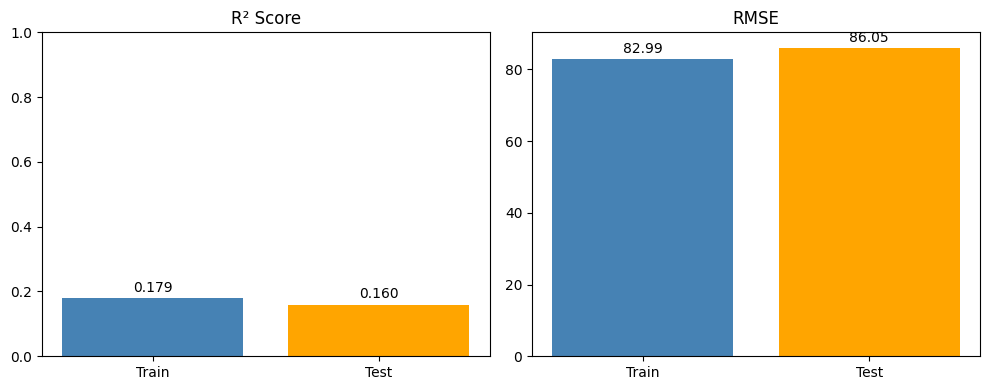

In [12]:
from sklearn.metrics import r2_score, root_mean_squared_error


train_r2 = r2_score(Y_train, y_train_pred)
test_r2 = r2_score(Y_test, y_test_pred)
train_rmse = root_mean_squared_error(Y_train, y_train_pred)
test_rmse = root_mean_squared_error(Y_test, y_test_pred)
print(f"Train R²: {train_r2:.4f}  |  Test R²: {test_r2:.4f}")
print(f"Train RMSE: {train_rmse:.4f}  |  Test RMSE: {test_rmse:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(['Train', 'Test'], [train_r2, test_r2], color=['steelblue', 'orange'])
axes[0].set_title('R² Score')
axes[0].set_ylim(0, 1)
for i, v in enumerate([train_r2, test_r2]):
    axes[0].text(i, v + 0.02, f"{v:.3f}", ha='center')

axes[1].bar(['Train', 'Test'], [train_rmse, test_rmse], color=['steelblue', 'orange'])
axes[1].set_title('RMSE')
for i, v in enumerate([train_rmse, test_rmse]):
    axes[1].text(i, v + max(train_rmse, test_rmse) * 0.02, f"{v:.2f}", ha='center')

plt.tight_layout()
plt.show()